# RQ1: Baseline Model Performance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv')
df.columns = df.columns.str.strip()
df = df.dropna()
print(df.columns)


Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')


In [3]:
# Define target and features
target = 'shopping_preference'
X = df.drop(columns=[target])
y = df[target]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='weighted'),
        recall_score(y_test, preds, average='weighted'),
        f1_score(y_test, preds, average='weighted')
    ])

results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1'])
print(results_df)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.960560   0.947662  0.960560  0.952389
1        Decision Tree  0.934690   0.933953  0.934690  0.934305
2                  KNN  0.912214   0.901413  0.912214  0.905742


In [5]:
# Save table
results_df.to_csv('/kaggle/working/RQ1_table.csv', index=False)


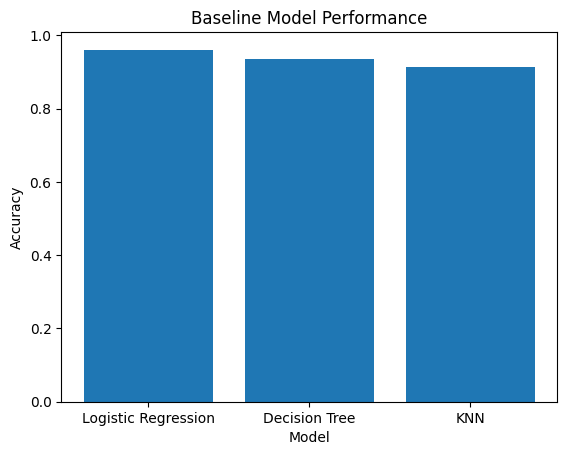

In [6]:
# Plot
plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Baseline Model Performance')
plt.savefig('/kaggle/working/RQ1_figure.pdf')
plt.show()
